Programa para realizar el ajuste lineal a los datos experimentales del flujo de muones atmosféricos frente a la altitud.

m = 0.00026161 ± 0.00001389 m^{-1}
n = -1.88603322 ± 0.02807091
chi2 = 79.5254
chi2 reducido = 11.3608
r (Pearson) = 0.994243


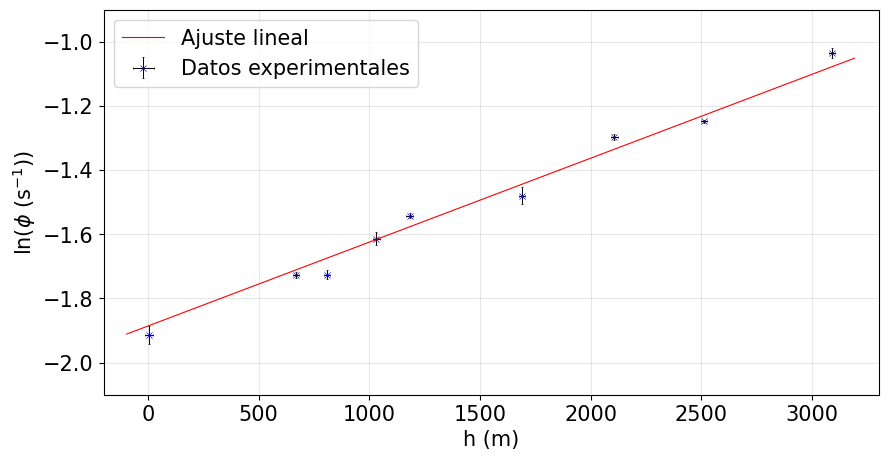

In [ ]:
##############################################################################################
# Introduzca el nombre del archivo con los datos a analizar en "Datos_Altitud_Flujo.txt",
# este archivo debe tener 4 columnas: altitud, incertidumbre altitud, flujo, incertidumbre flujo; y una primera fila con los nombres de las columnas.
# El programa generará una gráfica con el ajuste lineal realizado, la cual se guardará con el nombre "Ajuste_lineal.png" (puede cambiarlo si quiere),
# también devuelve un archivo txt con los parámetros del ajuste en "Parametros_ajuste.txt" (puede cambiarlo si quiere).
##############################################################################################

import numpy as np
import matplotlib.pyplot as plt

# Extraigo los datos del archivo en una matriz Nx4
Matriz_datos = np.loadtxt("Datos_Altitud_Flujo.txt", skiprows = 1)

# Extraigo las columnas de la matriz
Altitud = Matriz_datos[:, 0]
Inc_altitud = Matriz_datos[:, 1]
Flujo = Matriz_datos[:, 2]
Inc_flujo = Matriz_datos[:, 3]

# Calculo el ln(flujo)
ln_flujo = np.log(Flujo)

# Calculo su incertidumbre por propagación de errores
Inc_ln_flujo = Inc_flujo / Flujo

# Represento el ln(flujo) en función de la altitud
fig, ax = plt.subplots(figsize = (10, 5))
ax.set(xlim = (-200, 3300), ylim = (-2.1, -0.9))
ax.set_xlabel("h (m)", fontsize = 15)
ax.set_ylabel(r"ln($\phi$ (s$^{-1}$))", fontsize = 15)
ax.tick_params(axis = "both", labelsize = 15)

ax.errorbar(Altitud, ln_flujo, fmt = "x", markeredgewidth=0.5, markersize = 5, color = "blue", xerr = Inc_altitud, yerr = Inc_ln_flujo, ecolor = "black", elinewidth = 0.7, capsize = 1, capthick = 0.7, label = "Datos experimentales")

# Realizo una regresión lineal ponderada (peso = 1/sigma_y)
pesos = 1 / Inc_ln_flujo
coef, cov = np.polyfit(Altitud, ln_flujo, deg = 1, w = pesos, cov = True)
m, n = coef
inc_m, inc_n = np.sqrt(np.diag(cov))

# Calculo chi-cuadrado y chi-cuadrado reducido
ln_flujo_modelo = m * Altitud + n
chi2 = np.sum(((ln_flujo - ln_flujo_modelo) / Inc_ln_flujo) ** 2)
grados_libertad = len(Altitud) - 2
chi2_reducido = chi2 / grados_libertad

# Calculo el coeficiente de correlación lineal (Pearson)
r = np.corrcoef(Altitud, ln_flujo)[0, 1]

# Dibujo la recta de ajuste
h_ajuste = np.linspace(np.min(Altitud)-100, np.max(Altitud)+100, 200)
ln_flujo_ajuste = m * h_ajuste + n
ax.plot(h_ajuste, ln_flujo_ajuste, color = "red", linewidth = 0.8, label = "Ajuste lineal")
ax.grid(alpha=0.3)
ax.legend(loc = "upper left", fontsize = 15)

# Muestro resultados en consola
print(f"m = {m:.8f} ± {inc_m:.8f} m^{{-1}}")
print(f"n = {n:.8f} ± {inc_n:.8f}")
print(f"chi2 = {chi2:.4f}")
print(f"chi2 reducido = {chi2_reducido:.4f}")
print(f"r (Pearson) = {r:.6f}")

# Guardo los parámetros del ajuste
with open("Parametros_ajuste.txt", "w") as f:

    f.write(f"m = {m:.8f} ± {inc_m:.8f} (m^{{-1}}) \n")
    f.write(f"n = {n:.8f} ± {inc_n:.8f}\n")
    f.write(f"chi2 = {chi2:.4f}\n")
    f.write(f"chi2_reducido = {chi2_reducido:.4f}\n")
    f.write(f"r_pearson = {r:.6f}\n")

#Guardo el archivo generado
fig.savefig("Ajuste_lineal.png", dpi = 300)
plt.show()
